#### Importando Bibliotecas

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import seaborn as sns
import numpy as np


#### Entrada dos dados

In [4]:
df_andando = pd.read_csv("./arduino-science-jorunal/Andando.csv")
df_caminhando = pd.read_csv("./arduino-science-jorunal/Caminhando.csv")
df_correndo = pd.read_csv("./arduino-science-jorunal/Correndo.csv")

In [5]:
df_andando.head()

,timestamp,AmbientLightSensor,DecibelSource,PitchSensor,AccX,AccY,AccZ
0,1763074334936,1.0,NaN,NaN,-0.07605,2.08500,9.391951
1,1763074334953,NaN,48.155316,162.535924,NaN,NaN,NaN
2,1763074334958,NaN,NaN,85.885417,NaN,NaN,NaN
3,1763074334993,NaN,47.077705,85.885417,NaN,NaN,NaN
4,1763074335005,NaN,NaN,NaN,0.37305,2.07795,9.399000


In [6]:
df_caminhando.head()

,timestamp,AmbientLightSensor,DecibelSource,PitchSensor,AccX,AccY,AccZ
0,1763074862430,11.0,NaN,NaN,-0.15705,NaN,NaN
1,1763074862441,12.0,NaN,NaN,NaN,NaN,NaN
2,1763074862443,NaN,NaN,NaN,NaN,5.322,NaN
3,1763074862444,NaN,NaN,NaN,NaN,NaN,8.632951
4,1763074862447,NaN,NaN,NaN,-1.15095,NaN,NaN


In [7]:
df_correndo.head()

,timestamp,AmbientLightSensor,DecibelSource,PitchSensor,AccX,AccY,AccZ
0,1763141947708,NaN,NaN,NaN,2.622,-7.249050,6.73200
1,1763141947725,NaN,NaN,NaN,1.875,-9.009001,1.40205
2,1763141947727,NaN,67.496179,73.620199,NaN,NaN,NaN
3,1763141947744,NaN,NaN,NaN,0.330,-11.049001,NaN
4,1763141947745,NaN,NaN,NaN,NaN,NaN,-0.78795


#### Tamanho dos datasets

In [9]:
print(f"Número de instâncias(Andando): {len(df_andando['timestamp'])}")
print(f"Número de instâncias(Caminhando): {len(df_caminhando['timestamp'])}")
print(f"Número de instâncias(Correndo): {len(df_correndo['timestamp'])}")

Número de instâncias(Andando): 9660
Número de instâncias(Caminhando): 4833
Número de instâncias(Correndo): 3714


#### Verificar potenciais tratamentos de dados 

In [10]:
df_andando.dtypes

timestamp               int64
AmbientLightSensor    float64
DecibelSource         float64
PitchSensor           float64
AccX                  float64
AccY                  float64
AccZ                  float64
dtype: object

In [11]:
df_caminhando.dtypes

timestamp               int64
AmbientLightSensor    float64
DecibelSource         float64
PitchSensor           float64
AccX                  float64
AccY                  float64
AccZ                  float64
dtype: object

In [12]:
df_correndo.dtypes

timestamp               int64
AmbientLightSensor    float64
DecibelSource         float64
PitchSensor           float64
AccX                  float64
AccY                  float64
AccZ                  float64
dtype: object

#### Filtrando as features

In [13]:
df_filtrar_andando = df_andando[['timestamp', 'AccX', 'AccY', 'AccZ']]
df_filtrar_caminhando = df_caminhando[['timestamp', 'AccX', 'AccY', 'AccZ']]
df_filtrar_correndo = df_correndo[['timestamp', 'AccX', 'AccY', 'AccZ']]

In [14]:
df_filtrar_andando.head

<bound method NDFrame.head of           timestamp     AccX     AccY      AccZ
0     1763074334936 -0.07605  2.08500  9.391951
1     1763074334953      NaN      NaN       NaN
2     1763074334958      NaN      NaN       NaN
3     1763074334993      NaN      NaN       NaN
4     1763074335005  0.37305  2.07795  9.399000
...             ...      ...      ...       ...
9655  1763074424393      NaN      NaN       NaN
9656  1763074424404  0.47400  4.35705  8.496000
9657  1763074424405      NaN      NaN       NaN
9658  1763074424426      NaN  4.36200       NaN
9659  1763074424427  0.46005      NaN  8.491051

[9660 rows x 4 columns]>

#### Filtrando as Instâncias

In [15]:
df_filtrar_andando = df_filtrar_andando.dropna()
df_filtrar_caminhando = df_filtrar_caminhando.dropna()
df_filtrar_correndo = df_filtrar_correndo.dropna()

In [16]:
len(df_filtrar_andando)

3046

In [17]:

df_filtrar_andando.head()

,timestamp,AccX,AccY,AccZ
0,1763074334936,-0.07605,2.08500,9.391951
4,1763074335005,0.37305,2.07795,9.399000
5,1763074335021,2.26995,1.29705,9.388950
7,1763074335040,2.24805,0.94500,9.382051
9,1763074335059,1.75995,0.62895,8.950951


In [14]:
len(df_filtrar_caminhando)

843

In [18]:
len(df_filtrar_correndo)

731

In [19]:
df_filtrar_caminhando.head()

,timestamp,AccX,AccY,AccZ
7,1763074862463,-1.14795,4.02705,8.635051
8,1763074862487,-1.14105,2.94195,8.641951
10,1763074862503,-1.50795,2.96400,9.777000
17,1763074862562,-0.93300,3.82605,10.246051
19,1763074862589,-0.39405,3.83505,9.777000


In [20]:
len(df_filtrar_correndo)

731

In [21]:
df_filtrar_correndo.head()

,timestamp,AccX,AccY,AccZ
0,1763141947708,2.622000,-7.249050,6.73200
1,1763141947725,1.875000,-9.009001,1.40205
6,1763141947763,-0.652950,-14.439001,-2.77005
8,1763141947782,3.009000,-17.995050,-4.31505
18,1763141947860,28.518002,-5.590050,-4.31505


#### Nivelamento do Dataset

In [22]:
# Nível desejado
nivel_desejado = len(df_filtrar_correndo)  # 730

In [23]:
# Reduzir os outros DataFrames para 730 linhas (amostra aleatória)
df_filtrar_andando = df_filtrar_andando.sample(n=nivel_desejado, random_state=42)
df_filtrar_caminhando = df_filtrar_caminhando.sample(n=nivel_desejado, random_state=42)

In [24]:
# Verificar
print(f"Andando: {len(df_filtrar_andando)} linhas")
print(f"Caminhando: {len(df_filtrar_caminhando)} linhas") 
print(f"Correndo: {len(df_filtrar_correndo)} linhas")

Andando: 731 linhas
Caminhando: 731 linhas
Correndo: 731 linhas


#### Conferindo se tem Células Núlas

In [25]:
len(df_filtrar_caminhando)

731

In [26]:
len(df_filtrar_caminhando)


731

In [27]:
len(df_filtrar_caminhando)

731

In [26]:
df_filtrar_correndo.isna().any().any()


False

In [28]:
df_filtrar_caminhando.isna().any().any()


False

In [29]:
df_filtrar_andando.isna().any().any()

False

##### Resetar Índice

In [30]:
# Resetar índice começando do 1 (em vez do 0 padrão)
df_filtrar_correndo = df_filtrar_correndo.reset_index(drop=True)
df_filtrar_correndo.index = df_filtrar_correndo.index + 1

df_filtrar_andando = df_filtrar_andando.reset_index(drop=True)
df_filtrar_andando.index = df_filtrar_andando.index + 1

df_filtrar_caminhando = df_filtrar_caminhando.reset_index(drop=True)
df_filtrar_caminhando.index = df_filtrar_caminhando.index + 1

In [32]:
df_filtrar_correndo.head()

,timestamp,AccX,AccY,AccZ
1,1763141947708,2.622000,-7.249050,6.73200
2,1763141947725,1.875000,-9.009001,1.40205
3,1763141947763,-0.652950,-14.439001,-2.77005
4,1763141947782,3.009000,-17.995050,-4.31505
5,1763141947860,28.518002,-5.590050,-4.31505


In [33]:
df_filtrar_caminhando.head()


,timestamp,AccX,AccY,AccZ
1,1763074886587,5.86095,5.25495,6.163950
2,1763074873489,5.16195,7.95600,3.669000
3,1763074892646,-9.35805,2.28105,1.495050
4,1763074899122,4.08705,5.81505,5.869950
5,1763074865448,-1.60800,4.75995,10.167001


In [34]:
df_filtrar_andando.head()

,timestamp,AccX,AccY,AccZ
1,1763074366698,14.610001,-5.55405,0.00795
2,1763074355548,10.020000,-4.02405,-1.63995
3,1763074402851,10.200001,-1.06500,-1.67595
4,1763074378178,12.520051,-2.92500,-2.83005
5,1763074402251,11.184001,-1.74000,-0.69495


In [35]:
# Remover a última linha de cada DataFrame
df_filtrar_correndo = df_filtrar_correndo.iloc[:-1]  # Remove última linha
df_filtrar_andando = df_filtrar_andando.iloc[:-1]    # Remove última linha  
df_filtrar_caminhando = df_filtrar_caminhando.iloc[:-1]  # Remove última linha

In [36]:
len(df_filtrar_andando)

730

In [37]:
len(df_filtrar_caminhando)

730

In [38]:
len(df_filtrar_correndo)

730

#### Concatenação dos Dataframes

In [39]:
# Número total desejado
n_total = 730
tamanho_bloco = 10

# Lista para armazenar os blocos
blocos = []

# Calcular quantos blocos completos cabem em 730 instâncias
num_blocos = n_total // (3 * tamanho_bloco)  # 3 atividades × 10 exemplos cada

# Adicionar blocos completos
for i in range(num_blocos):
    # Pegar 10 exemplos de cada atividade para este bloco
    correndo_bloco = df_filtrar_correndo.iloc[i*tamanho_bloco:(i+1)*tamanho_bloco].assign(atividade='Correndo')
    andando_bloco = df_filtrar_andando.iloc[i*tamanho_bloco:(i+1)*tamanho_bloco].assign(atividade='Andando')
    caminhando_bloco = df_filtrar_caminhando.iloc[i*tamanho_bloco:(i+1)*tamanho_bloco].assign(atividade='Caminhando')
    
    # Concatenar na sequência: Correndo -> Andando -> Caminhando
    bloco_completo = pd.concat([correndo_bloco, andando_bloco, caminhando_bloco], ignore_index=True)
    blocos.append(bloco_completo)

# Concatenar todos os blocos
df_sequencia = pd.concat(blocos, ignore_index=True)

# Verificar se precisamos adicionar mais instâncias para completar 730
instancias_restantes = n_total - len(df_sequencia)

if instancias_restantes > 0:
    # Calcular de qual atividade e posição começar
    bloco_atual = num_blocos
    atividade_index = 0  # 0=Correndo, 1=Andando, 2=Caminhando
    
    while instancias_restantes > 0:
        if atividade_index == 0:  # Correndo
            df_atual = df_filtrar_correndo
            atividade = 'Correndo'
        elif atividade_index == 1:  # Andando
            df_atual = df_filtrar_andando
            atividade = 'Andando'
        else:  # Caminhando
            df_atual = df_filtrar_caminhando
            atividade = 'Caminhando'
        
        # Pegar próximo exemplo disponível
        inicio = bloco_atual * tamanho_bloco
        fim = inicio + min(instancias_restantes, tamanho_bloco)
        
        if inicio < len(df_atual):
            exemplos_extra = df_atual.iloc[inicio:fim].assign(atividade=atividade)
            df_sequencia = pd.concat([df_sequencia, exemplos_extra], ignore_index=True)
            instancias_restantes -= len(exemplos_extra)
        
        atividade_index = (atividade_index + 1) % 3
        if atividade_index == 0:
            bloco_atual += 1

# Resetar índice para 1, 2, 3...
df_sequencia.index = df_sequencia.index + 1

In [40]:
df_sequencia.head(60)

,timestamp,AccX,AccY,AccZ,atividade
1,1763141947708,2.622000,-7.249050,6.732000,Correndo
2,1763141947725,1.875000,-9.009001,1.402050,Correndo
3,1763141947763,-0.652950,-14.439001,-2.770050,Correndo
4,1763141947782,3.009000,-17.995050,-4.315050,Correndo
5,1763141947860,28.518002,-5.590050,-4.315050,Correndo
6,1763141947899,50.128952,8.767950,-2.785050,Correndo
7,1763141947938,31.345951,13.824000,0.612000,Correndo
8,1763141947977,12.964951,14.557051,6.882000,Correndo
9,1763141947996,8.812950,15.088951,7.708050,Correndo
10,1763141948016,4.590000,15.097951,7.708050,Correndo


In [41]:
# Remover a coluna timestamp
df_sequencia = df_sequencia.drop('timestamp', axis=1)


df_sequencia.head(60)

,AccX,AccY,AccZ,atividade
1,2.622000,-7.249050,6.732000,Correndo
2,1.875000,-9.009001,1.402050,Correndo
3,-0.652950,-14.439001,-2.770050,Correndo
4,3.009000,-17.995050,-4.315050,Correndo
5,28.518002,-5.590050,-4.315050,Correndo
6,50.128952,8.767950,-2.785050,Correndo
7,31.345951,13.824000,0.612000,Correndo
8,12.964951,14.557051,6.882000,Correndo
9,8.812950,15.088951,7.708050,Correndo
10,4.590000,15.097951,7.708050,Correndo


#### Visualização das Amostras

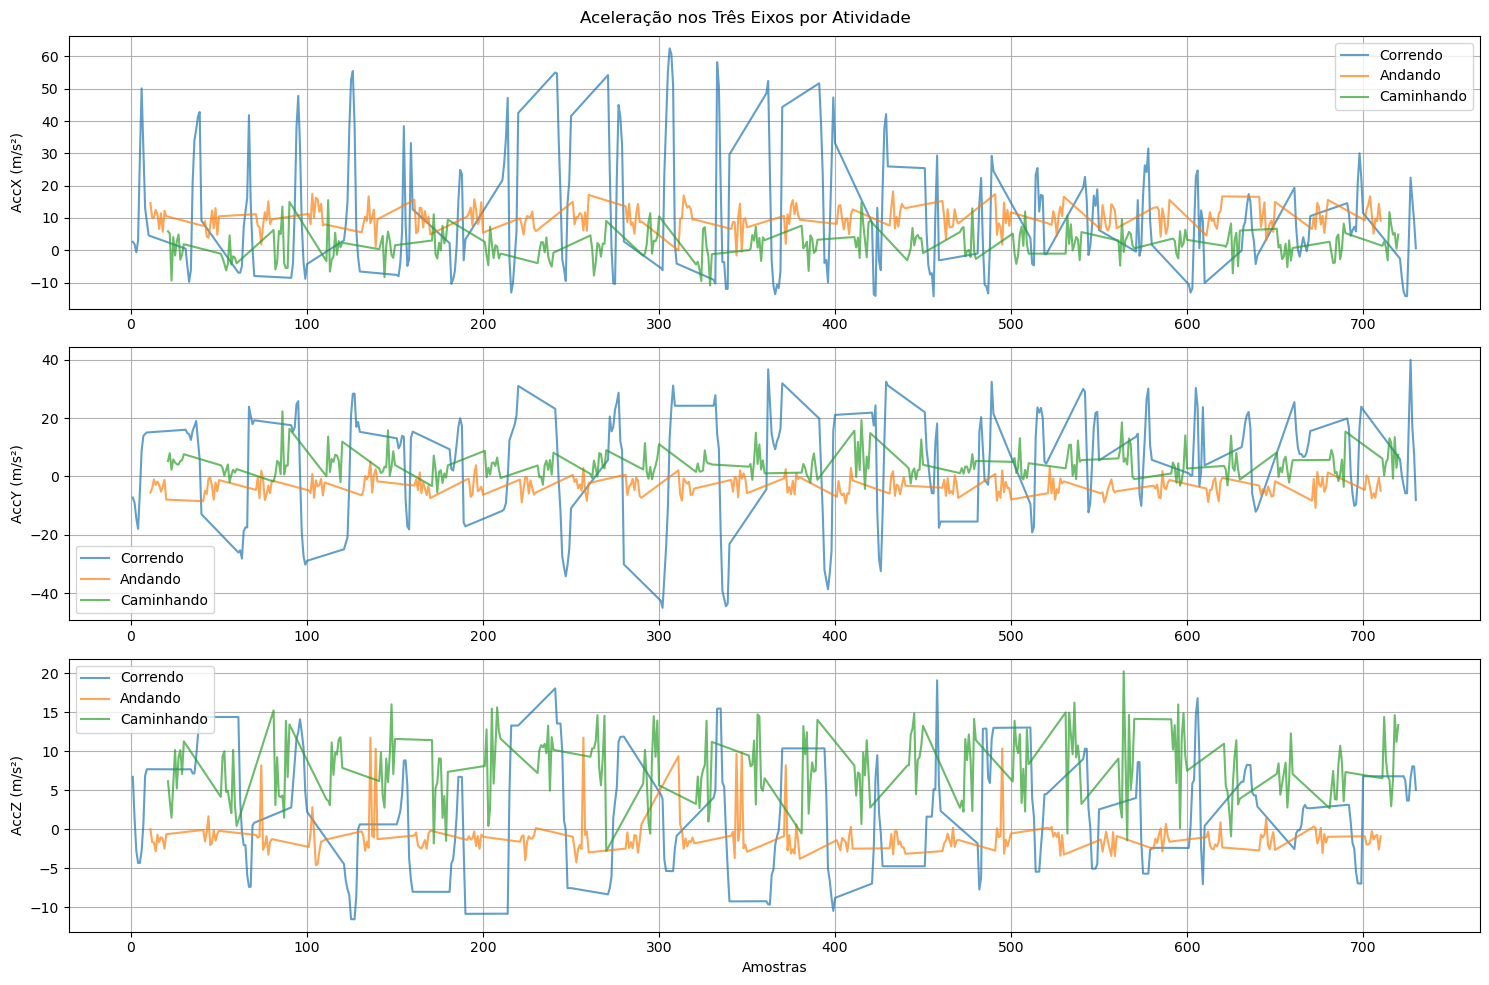

In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Plot cada eixo separadamente
for i, eixo in enumerate(['AccX', 'AccY', 'AccZ']):
    for atividade in df_sequencia['atividade'].unique():
        dados = df_sequencia[df_sequencia['atividade'] == atividade]
        axes[i].plot(dados.index, dados[eixo], label=atividade, alpha=0.7)
    
    axes[i].set_ylabel(f'{eixo} (m/s²)')
    axes[i].legend()
    axes[i].grid(True)

axes[2].set_xlabel('Amostras')
plt.suptitle('Aceleração nos Três Eixos por Atividade')
plt.tight_layout()
plt.show()

In [43]:
# Codificar a variável 'atividade' para valores numéricos
le = LabelEncoder()
df_sequencia['atividade_lb'] = le.fit_transform(df_sequencia['atividade'])

# Ver o mapeamento
print("Mapeamento das atividades:")
for i, atividade in enumerate(le.classes_):
    print(f"{atividade}: {i}")

Mapeamento das atividades:
Andando: 0
Caminhando: 1
Correndo: 2


##### Importação do Dataset

In [44]:
# Exportar para CSV
df_sequencia.to_csv('sequencia.csv', index=False)

print("DataFrame exportado com sucesso para 'sequencia.csv'")

DataFrame exportado com sucesso para 'sequencia.csv'


In [45]:
df_sequencia.head(100)

,AccX,AccY,AccZ,atividade,atividade_lb
1,2.622000,-7.249050,6.732000,Correndo,2
2,1.875000,-9.009001,1.402050,Correndo,2
3,-0.652950,-14.439001,-2.770050,Correndo,2
4,3.009000,-17.995050,-4.315050,Correndo,2
5,28.518002,-5.590050,-4.315050,Correndo,2
...,...,...,...,...,...
96,32.014053,0.996000,14.116051,Correndo,2
97,8.173950,-19.201052,12.448951,Correndo,2
98,-3.655050,-27.325050,10.474051,Correndo,2
99,-8.820001,-30.262951,4.771050,Correndo,2


#### Divisão dos dados

In [46]:
# Divisão dos dados em features e target
X = df_sequencia[['AccX', 'AccY', 'AccZ']]
y = df_sequencia['atividade_lb']


#### Divisão em treino e teste

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

#### Criação do Classificador

In [48]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42,max_depth=10,min_samples_split=5,min_samples_leaf=2)

#### Treinar o Classificador

In [49]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       random_state=42)

#### Realizar a previsão

In [50]:
y_pred = rf_model.predict(X_test)

In [53]:
# Métricas de avaliação
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAcurácia do modelo: {accuracy:.4f}")

print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Acurácia do modelo: 0.8995

Relatório de classificação:
              precision    recall  f1-score   support

     Andando       1.00      0.92      0.96        72
  Caminhando       0.81      0.92      0.86        72
    Correndo       0.90      0.87      0.88        75

    accuracy                           0.90       219
   macro avg       0.91      0.90      0.90       219
weighted avg       0.91      0.90      0.90       219



#### MATRIZ DE CONFUSÃO 

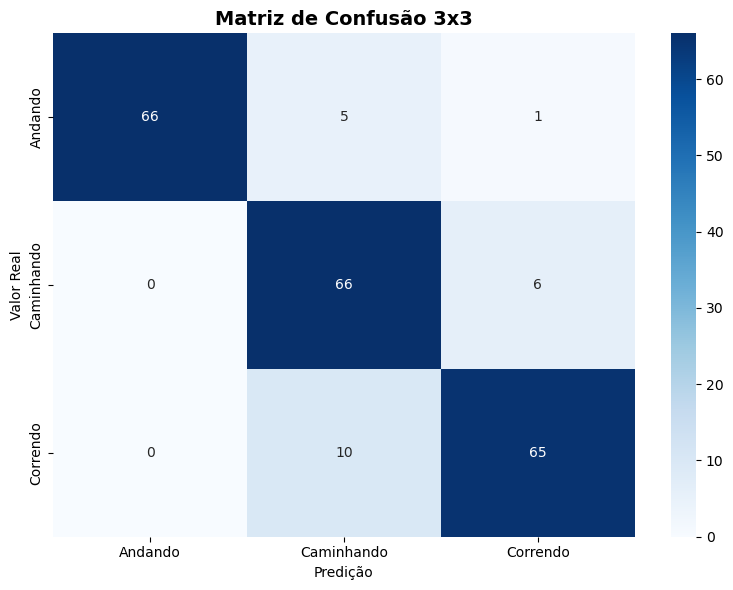

In [52]:
# Matriz de confusão normal 3x3
cm = confusion_matrix(y_test, y_pred)

# Plotar matriz 3x3
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.title('Matriz de Confusão 3x3', fontsize=14, fontweight='bold')
plt.ylabel('Valor Real')
plt.xlabel('Predição')
plt.tight_layout()
plt.show()


- Classe "Andando"
    - 201 vezes foi classificada corretamente como "Andando"
    - 8 vezes foi classificada erroneamente como "Caminhando"
    - 10 vezes foi classificada erroneamente como "Correndo"

- Classe "Caminhando"
    - 185 vezes foi classificada corretamente como "Caminhando"
    - 3 vezes foi classificada erroneamente como "Andando"
    - 31 vezes foi classificada erroneamente como "Correndo"

- Classe "Correndo"
    - 151 vezes foi classificada corretamente como "Correndo"
    - 8 vezes foi classificada erroneamente como "Andando"
    - 60 vezes foi classificada erroneamente como "Caminhando"

#### ANÁLISE TP, TN, FP, FN PARA CADA CLASSE

In [54]:
for i, classe in enumerate(le.classes_):
    # Converter para problema binário
    y_true_binary = (y_test == i).astype(int)
    y_pred_binary = (y_pred == i).astype(int)
    
    # Calcular matriz binária
    cm_binary = confusion_matrix(y_true_binary, y_pred_binary)
    TN, FP, FN, TP = cm_binary.ravel()
    
    print(f"\n{classe} (Classe {i}):")
    print(f"  TP: {TP} - {classe} corretamente identificado como {classe}")
    print(f"  TN: {TN} - Outras classes corretamente identificadas como outras")
    print(f"  FP: {FP} - Outras classes erroneamente identificadas como {classe}")
    print(f"  FN: {FN} - {classe} erroneamente identificado como outras classes")





Andando (Classe 0):
  TP: 66 - Andando corretamente identificado como Andando
  TN: 147 - Outras classes corretamente identificadas como outras
  FP: 0 - Outras classes erroneamente identificadas como Andando
  FN: 6 - Andando erroneamente identificado como outras classes

Caminhando (Classe 1):
  TP: 66 - Caminhando corretamente identificado como Caminhando
  TN: 132 - Outras classes corretamente identificadas como outras
  FP: 15 - Outras classes erroneamente identificadas como Caminhando
  FN: 6 - Caminhando erroneamente identificado como outras classes

Correndo (Classe 2):
  TP: 65 - Correndo corretamente identificado como Correndo
  TN: 137 - Outras classes corretamente identificadas como outras
  FP: 7 - Outras classes erroneamente identificadas como Correndo
  FN: 10 - Correndo erroneamente identificado como outras classes


#### RESUMO DA MATRIZ

In [55]:
total_amostras = len(y_test)
acertos_totais = cm.trace()
erros_totais = total_amostras - acertos_totais

print(f"Total de amostras: {total_amostras}")
print(f"Acertos totais (diagonal): {acertos_totais}")
print(f"Erros totais: {erros_totais}")
print(f"Acurácia: {acertos_totais/total_amostras:.3f}")

Total de amostras: 219
Acertos totais (diagonal): 197
Erros totais: 22
Acurácia: 0.900
